In [1]:
!pip3 install -U scikit-learn

In [4]:
import sqlite3
import pandas as pd
from sklearn.model_selection import train_test_split #separar datos del modelo
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error # error cuadratico medio
from math import sqrt
from sklearn import preprocessing # preprocesamiento de datos
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
import numpy as np

### Creacióm de la conexión a la base de datos para leer la tabla "Player Attributes"

In [5]:
cnx = sqlite3.connect('database.sqlite')

In [6]:
df = pd.read_sql_query("SELECT * FROM Player_Attributes", cnx)

In [5]:
df.head()

,id,player_fifa_api_id,player_api_id,date,overall_rating,potential,preferred_foot,attacking_work_rate,defensive_work_rate,crossing,...,vision,penalties,marking,standing_tackle,sliding_tackle,gk_diving,gk_handling,gk_kicking,gk_positioning,gk_reflexes
0,1,218353,505942,2016-02-18 00:00:00,67.0,71.0,right,medium,medium,49.0,...,54.0,48.0,65.0,69.0,69.0,6.0,11.0,10.0,8.0,8.0
1,2,218353,505942,2015-11-19 00:00:00,67.0,71.0,right,medium,medium,49.0,...,54.0,48.0,65.0,69.0,69.0,6.0,11.0,10.0,8.0,8.0
2,3,218353,505942,2015-09-21 00:00:00,62.0,66.0,right,medium,medium,49.0,...,54.0,48.0,65.0,66.0,69.0,6.0,11.0,10.0,8.0,8.0
3,4,218353,505942,2015-03-20 00:00:00,61.0,65.0,right,medium,medium,48.0,...,53.0,47.0,62.0,63.0,66.0,5.0,10.0,9.0,7.0,7.0
4,5,218353,505942,2007-02-22 00:00:00,61.0,65.0,right,medium,medium,48.0,...,53.0,47.0,62.0,63.0,66.0,5.0,10.0,9.0,7.0,7.0


In [6]:
df.shape # filas y columnas de la tabla

(183978, 42)

In [7]:
df.columns # muestra las columnas del dataset

Index(['id', 'player_fifa_api_id', 'player_api_id', 'date', 'overall_rating',
       'potential', 'preferred_foot', 'attacking_work_rate',
       'defensive_work_rate', 'crossing', 'finishing', 'heading_accuracy',
       'short_passing', 'volleys', 'dribbling', 'curve', 'free_kick_accuracy',
       'long_passing', 'ball_control', 'acceleration', 'sprint_speed',
       'agility', 'reactions', 'balance', 'shot_power', 'jumping', 'stamina',
       'strength', 'long_shots', 'aggression', 'interceptions', 'positioning',
       'vision', 'penalties', 'marking', 'standing_tackle', 'sliding_tackle',
       'gk_diving', 'gk_handling', 'gk_kicking', 'gk_positioning',
       'gk_reflexes'],
      dtype='str')

### De todas las columnas, determinaremos cuales se usarán con "Features" para alimentar al modelo

In [8]:
features = ['potential', 'crossing', 'finishing', 'heading_accuracy',
       'short_passing', 'volleys', 'dribbling', 'curve', 'free_kick_accuracy',
       'long_passing', 'ball_control', 'acceleration', 'sprint_speed',
       'agility', 'reactions', 'balance', 'shot_power', 'jumping', 'stamina',
       'strength', 'long_shots', 'aggression', 'interceptions', 'positioning',
       'vision', 'penalties', 'marking', 'standing_tackle', 'sliding_tackle',
       'gk_diving', 'gk_handling', 'gk_kicking', 'gk_positioning', 'gk_reflexes']

### Seleccionamos el target

In [9]:
target = ['overall_rating']

### Limpiar los datos eliminando filas con valores nan

In [10]:
df = df.dropna()

### Separamos las features en X, y el target en Y

In [11]:
X = df[features] # caracteristicas elegidas
y = df[target]

### Mostrar el contenido de una fila de conjunto X

In [14]:
X.iloc[2043]

potential             68.0
crossing              38.0
finishing             59.0
heading_accuracy      72.0
short_passing         62.0
volleys               63.0
dribbling             48.0
curve                 43.0
free_kick_accuracy    45.0
long_passing          57.0
ball_control          49.0
acceleration          59.0
sprint_speed          72.0
agility               73.0
reactions             66.0
balance               73.0
shot_power            45.0
jumping               76.0
stamina               68.0
strength              57.0
long_shots            46.0
aggression            62.0
interceptions         17.0
positioning           71.0
vision                56.0
penalties             73.0
marking               17.0
standing_tackle       27.0
sliding_tackle        11.0
gk_diving             10.0
gk_handling           10.0
gk_kicking            10.0
gk_positioning        10.0
gk_reflexes            8.0
Name: 2086, dtype: float64

In [13]:
X.head()

,potential,crossing,finishing,heading_accuracy,short_passing,volleys,dribbling,curve,free_kick_accuracy,long_passing,...,vision,penalties,marking,standing_tackle,sliding_tackle,gk_diving,gk_handling,gk_kicking,gk_positioning,gk_reflexes
0,71.0,49.0,44.0,71.0,61.0,44.0,51.0,45.0,39.0,64.0,...,54.0,48.0,65.0,69.0,69.0,6.0,11.0,10.0,8.0,8.0
1,71.0,49.0,44.0,71.0,61.0,44.0,51.0,45.0,39.0,64.0,...,54.0,48.0,65.0,69.0,69.0,6.0,11.0,10.0,8.0,8.0
2,66.0,49.0,44.0,71.0,61.0,44.0,51.0,45.0,39.0,64.0,...,54.0,48.0,65.0,66.0,69.0,6.0,11.0,10.0,8.0,8.0
3,65.0,48.0,43.0,70.0,60.0,43.0,50.0,44.0,38.0,63.0,...,53.0,47.0,62.0,63.0,66.0,5.0,10.0,9.0,7.0,7.0
4,65.0,48.0,43.0,70.0,60.0,43.0,50.0,44.0,38.0,63.0,...,53.0,47.0,62.0,63.0,66.0,5.0,10.0,9.0,7.0,7.0


In [15]:
y.head()

,overall_rating
0,67.0
1,67.0
2,62.0
3,61.0
4,61.0


### Muestreo de los valores de la feature "reactions" para cada jugador

In [16]:
X['reactions']

0         47.0
1         47.0
2         47.0
3         46.0
4         46.0
          ... 
183973    86.0
183974    74.0
183975    74.0
183976    69.0
183977    66.0
Name: reactions, Length: 180354, dtype: float64

### Imprimir la relación existente entre el feature "reactions" y el target "overall_rating"

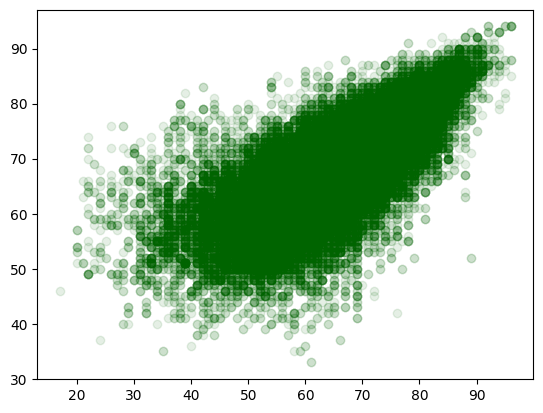

In [17]:
plt.scatter(X['reactions'], y, color = 'darkgreen', label = 'Datos', alpha = .1)

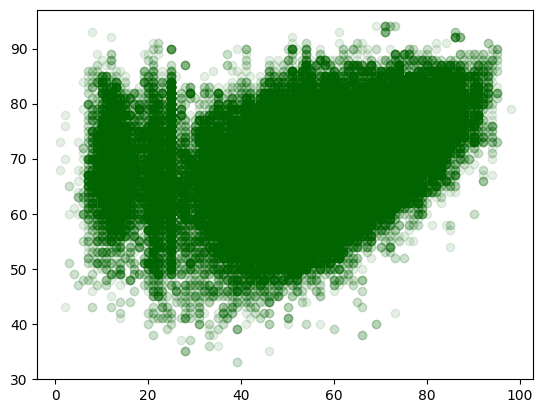

In [19]:
plt.scatter(X['heading_accuracy'], y, color = 'darkgreen', label = 'Datos', alpha = .1)

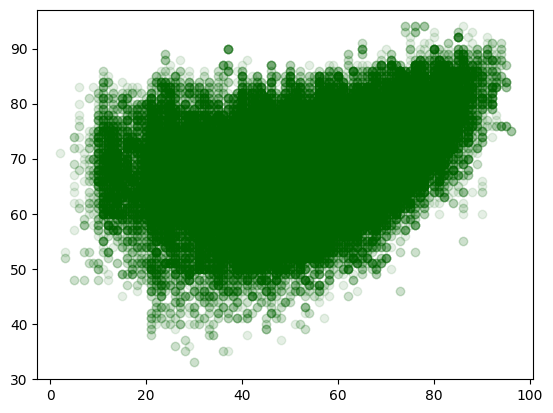

In [20]:
plt.scatter(X['penalties'], y, color = 'darkgreen', label = 'Datos', alpha = .1)

# Entrenamiento del modelo

### Separación de los datos en Training y Test Datasets

In [22]:
# X_train para entrenar
X_train , X_test, y_train, y_test = train_test_split(X, y, test_size = 0.33, random_state= 324)

### Utilizar un escalado estandar

Sesgo: cuando una o varias caracteristicas pueden influir en el entrenamiento
Para que los datos de cada feature se acople a un rango y se eviten los sesgos de un feature con valores muy altos que puedan influir de mas en el target

In [24]:
scale = preprocessing.StandardScaler()

In [25]:
scale.fit(X_train)

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [26]:
X_train = scale.transform(X_train)

In [27]:
# imprimir los nuevos valores minimo y máximo de los valores de entrenamiento
X_train.min()

np.float64(-5.377337896778157)

In [28]:
X_train.max()

np.float64(4.9683467491419835)

### Creamos una instancia del modelo de Regresión lineal de Scikit Learn

In [29]:
regresor = LinearRegression()

### Ajustando el modelo a los datos de entrenamiento

In [ ]:
regresor.fit(X_train, y_train)

### Realizar una predicción usando el conjunto de datos de pruebas (test set)

In [32]:
# Escalar valores de prueba para que coincidan con los de entrenamiento
X_test = scale.transform(X_test)

In [34]:
# Hacer una predicción del valor de salida, pasandole los valores de prueba
y_prediccion = regresor.predict(X_test)

In [36]:
# Obtener diferencia que hay entre los valores de salida predichos contra los valores de salida reales
y_result = y_prediccion - y_test
y_result

,overall_rating
35543,0.512849
28735,-3.227654
168029,1.573718
138117,0.990422
123316,1.203533
...,...
51151,-1.920947
155333,-1.253060
118067,-1.762199
62126,2.583517


### Calcular la raíz cuadrada del Error Cuadrático Medio

In [37]:
RMSE = sqrt(mean_squared_error(y_true = y_test, y_pred = y_prediccion))
print(RMSE)

2.805303046855211


### Mostrar la precisión que obtuvo el modelo al predecir con los valores de prueba

In [38]:
regresor.score(X_test, y_test)

0.8412690897596594

### Mostrar cual es el valor de cada w que se aplicó a cada feature (w * X) para que al sumar todos los productos nos de el puntaje de cada jugador

In [39]:
regresor.coef_

array([[ 2.48175418,  0.37435166,  0.2155902 ,  1.14537904,  0.72579619,
         0.08835762, -0.2396529 ,  0.20341906,  0.23070925,  0.08573083,
         2.03147644,  0.08063536,  0.11593773, -0.09744622,  1.92780373,
         0.10753058,  0.27833167,  0.16277628, -0.08089224,  0.73874625,
        -0.25048481,  0.33897633,  0.22293067, -0.18511046, -0.01892236,
         0.21517621,  0.70526674,  0.07880386, -0.61339243,  2.72376613,
         0.51832172, -0.70907673,  0.91420565,  0.43578429]])

In [40]:
regresor.intercept_

array([68.63507038])

# EJERCICIO: MEJORAR LA PRECISIÓN

In [7]:
features0 = ['potential', 'crossing', 'finishing', 'heading_accuracy',
       'short_passing', 'volleys', 'dribbling', 'curve', 'free_kick_accuracy',
       'long_passing', 'ball_control', 'acceleration', 'sprint_speed',
       'agility', 'reactions', 'balance', 'shot_power', 'jumping', 'stamina',
       'strength', 'long_shots', 'aggression', 'interceptions',
       'vision', 'penalties', 'marking', 'standing_tackle', 'sliding_tackle',
       'gk_diving', 'gk_handling', 'gk_kicking', 'gk_positioning', 'gk_reflexes']

In [8]:
target = ['overall_rating']
df = df.dropna()
X = df[features0] # caracteristicas elegidas
y = df[target]
# X_train para entrenar
X_train , X_test, y_train, y_test = train_test_split(X, y, test_size = 0.33, random_state= 324)
scale = preprocessing.StandardScaler()
scale.fit(X_train)

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [11]:
X_train = scale.transform(X_train)
regresor = LinearRegression()
regresor.fit(X_train, y_train)
# Escalar valores de prueba para que coincidan con los de entrenamiento
X_test = scale.transform(X_test)
y_prediccion = regresor.predict(X_test)
y_result = y_prediccion - y_test
RMSE = sqrt(mean_squared_error(y_true = y_test, y_pred = y_prediccion))
regresor.score(X_test, y_test)

0.8410725003156283

bajo la precision al quitar la caracteristica de 'positioning'

Al quitar dribbling baja 0.0000982179937257

Al quitar acceleration baja 0.0000321415925249

Al quitar sprint_speed baja 0.0000341352660017

Al quitar stamina baja 0.0000034603984976

Al quitar vision baja 0.0000084419800653

Al quitar standing_tackle baja 0.0000013320726217

## MAS CASOS

In [151]:
features0 = ['potential', 'crossing', 'finishing', 'heading_accuracy',
       'short_passing', 'volleys', 'dribbling', 'curve', 'free_kick_accuracy',
       'long_passing', 'ball_control', 'acceleration', 'sprint_speed',
       'agility', 'reactions', 'balance', 'shot_power', 'jumping', 'stamina',
       'strength', 'long_shots', 'aggression', 'interceptions', 'positioning',
       'vision', 'penalties', 'marking', 'standing_tackle', 'sliding_tackle',
       'gk_diving', 'gk_handling', 'gk_kicking', 'gk_positioning', 'gk_reflexes']

In [158]:
target = ['overall_rating']
df = df.dropna()
X = df[features0] # caracteristicas elegidas
y = df[target]
# X_train para entrenar
X_train , X_test, y_train, y_test = train_test_split(X, y, test_size = 0.30, random_state= 324)
scale = preprocessing.StandardScaler()
scale.fit(X_train)
X_train = scale.transform(X_train)
regresor = LinearRegression()
regresor.fit(X_train, y_train)
# Escalar valores de prueba para que coincidan con los de entrenamiento
X_test = scale.transform(X_test)
y_prediccion = regresor.predict(X_test)
y_result = y_prediccion - y_test
RMSE = sqrt(mean_squared_error(y_true = y_test, y_pred = y_prediccion))
regresor.score(X_test, y_test)

0.8419989373549774

### Mejoras

Al poner 'test_size = 0.30' el RESULTADO ES: 0.8419989373549774, por lo cual, se obtiene una mejora con diferencia de 0.000729847595318 

## MAS PRUEBAS

In [303]:
features0 = ['potential', 'crossing', 'finishing', 'heading_accuracy',
       'short_passing',  'dribbling', 'curve', 'free_kick_accuracy',
       'long_passing', 'ball_control', 'acceleration', 'sprint_speed',
       'agility', 'reactions', 'balance', 'shot_power', 'jumping', 'stamina',
       'strength', 'long_shots', 'aggression', 'interceptions', 'positioning',
       'vision', 'penalties', 'marking', 'standing_tackle', 'sliding_tackle',
       'gk_diving', 'gk_handling', 'gk_kicking', 'gk_positioning', 'gk_reflexes']
       
target = ['overall_rating']
df = df.dropna()
X = df[features0] # caracteristicas elegidas
y = df[target]
# X_train para entrenar
X_train , X_test, y_train, y_test = train_test_split(X, y, test_size = 0.33, random_state= 324)
scale = preprocessing.StandardScaler()
scale.fit(X_train)
X_train = scale.transform(X_train)
regresor = LinearRegression()
regresor.fit(X_train, y_train)
# Escalar valores de prueba para que coincidan con los de entrenamiento
X_test = scale.transform(X_test)
y_prediccion = regresor.predict(X_test)
y_result = y_prediccion - y_test
RMSE = sqrt(mean_squared_error(y_true = y_test, y_pred = y_prediccion))
regresor.score(X_test, y_test)

0.8412611572903863

#### Dato obtenido a mejorar: 0.8412690897596594

podria quitar potential
ball control
reactions
jumpin
strength
agresion
interceptions penalties
sliding tacle
0.8374577489222786
0.8412611572903863


In [ ]:
['potential', 'crossing', 'finishing', 'heading_accuracy',
       'short_passing', 'dribbling', 'curve', 
       'long_passing', 'ball_control', 'acceleration', 'sprint_speed',
       'agility', 'reactions', 'balance', 'shot_power', 'jumping', 'stamina',
       'strength', 'long_shots', 'aggression', 'interceptions', 'positioning',
       'vision', 'penalties', 'marking', 'standing_tackle', 'sliding_tackle',
       'gk_diving', 'gk_kicking', 'gk_positioning', 'gk_reflexes']

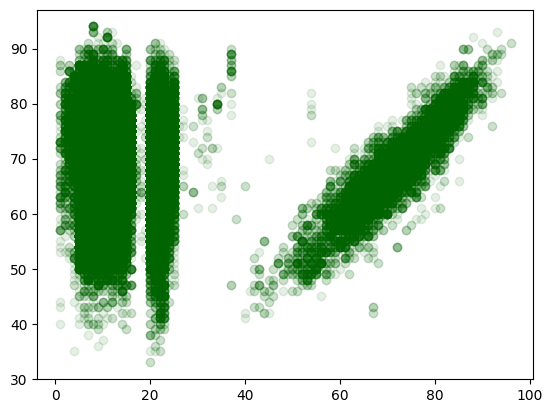

In [301]:
plt.scatter(X['gk_reflexes'], y, color = 'darkgreen', label = 'Datos', alpha = .1)

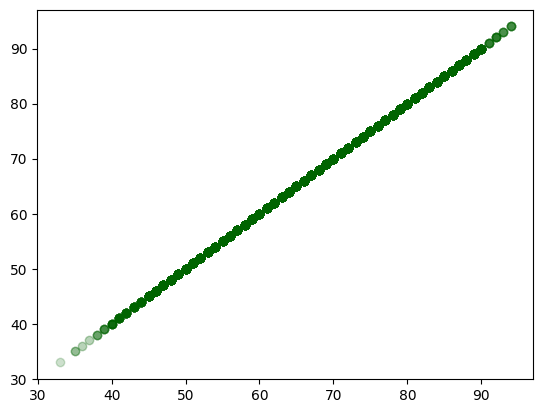

In [304]:
plt.scatter(y['overall_rating'], y, color = 'darkgreen', label = 'Datos', alpha = .1)

## Conclusión

Se graficaron cada una de las caracteristicas (features), las cuales mayormente se acoplaban la interseccion del target (Y) overall_rating, de igual forma se estuvieron quitando e intercalando las features del modelo, por ejemplo, al quitar la caracteristica 'standing_tackle' la precision baja 0.0000013320726217 la cual fue la mas minima diferencia, sin embargo, no se obtuvo un aumento en la precision del modelo al modificar los features, por otro lado, al modificar el tamaño de prueba 'test_size' a 0.30 se obtuvo un aumento de *0.000729847595318*.